In [45]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
data = np.load('prepare_data/target_id2.npy')

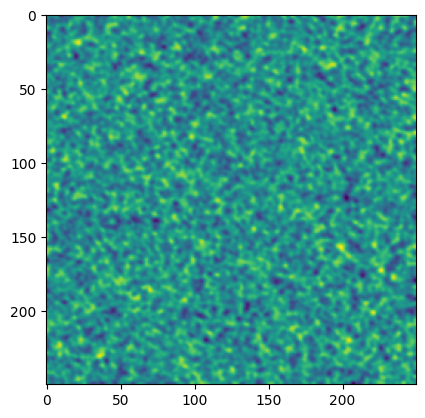

In [47]:
plt.imshow(data[0])

In [48]:
from scipy.signal import correlate2d


In [49]:
acf = correlate2d(data[0], data[0], mode='same')
acf /= acf[acf.shape[1]//2, acf.shape[0]//2]

In [52]:
import numpy as np

def acf_to_covariance_masked(acf, noise_map, mask=None):
    if mask is None:
        mask = np.ones(noise_map.shape, dtype=bool)  # use all pixels by default

    sigma2 = np.nanvar(noise_map)
    cy, cx = acf.shape[0] // 2, acf.shape[1] // 2

    # Pixel coordinates in the noise map
    ys, xs = np.where(mask)
    coords = np.stack([ys, xs], axis=1)  # (N, 2)

    # All pairwise separations
    dy, dx = (coords[:, None] - coords[None, :]).transpose(2, 0, 1)

    # Clip to ACF bounds (valid if ACF decays to 0 at edges)
    iy = np.clip(cy + dy, 0, acf.shape[0] - 1)
    ix = np.clip(cx + dx, 0, acf.shape[1] - 1)

    C = sigma2 * acf[iy, ix]
    return C

# Typical usage: pass an aperture mask over the noise map
ny, nx = data[0].shape
y, x = np.mgrid[0:ny, 0:nx]
aperture_mask = (y - ny//2)**2 + (x - nx//2)**2 < 20**2  # circular aperture

C = acf_to_covariance_masked(acf, data[0], mask=None)

KeyboardInterrupt: 

In [51]:
C

array([[1.68867340e-06, 1.87820394e-06, 1.63692215e-06, ...,
        4.27096350e-08, 4.19609285e-08, 3.53496957e-08],
       [1.20383568e-06, 1.68867340e-06, 1.87820394e-06, ...,
        3.81902344e-08, 4.27096350e-08, 4.19609285e-08],
       [6.75862356e-07, 1.20383568e-06, 1.68867340e-06, ...,
        3.10208028e-08, 3.81902344e-08, 4.27096350e-08],
       ...,
       [2.19586276e-08, 2.61033881e-08, 2.63653653e-08, ...,
        1.68867340e-06, 1.87820394e-06, 1.63692215e-06],
       [1.85161226e-08, 2.19586276e-08, 2.61033881e-08, ...,
        1.20383568e-06, 1.68867340e-06, 1.87820394e-06],
       [1.95306708e-08, 1.85161226e-08, 2.19586276e-08, ...,
        6.75862356e-07, 1.20383568e-06, 1.68867340e-06]],
      shape=(1245, 1245))

In [39]:
invC = np.linalg.inv(C)

In [44]:
250**2

62500

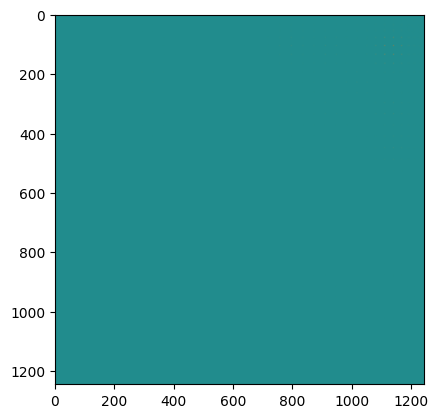

In [42]:
plt.imshow(invC)

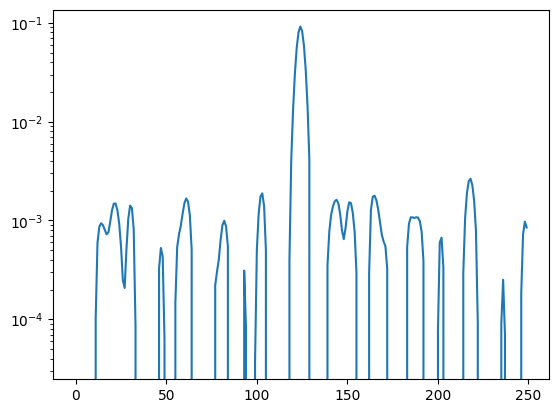

In [30]:
plt.plot(res[125])
plt.yscale('log')